In [ ]:
# da workload standard a più utilizzo o meno utilizzo.

import json
import random

with open("1024_nodes_v5.json", "r") as f:
    data = json.load(f)

for job in data.get("jobs", []):
    if job.get("res", 0) > 1:
        if random.random() < 0.5:  # 50% di probabilità
            job["res"] = job["res"] // 2  # resta intero

with open("workload_2000jobs_1024nodes_60.json", "w") as f:
    json.dump(data, f, indent=2)

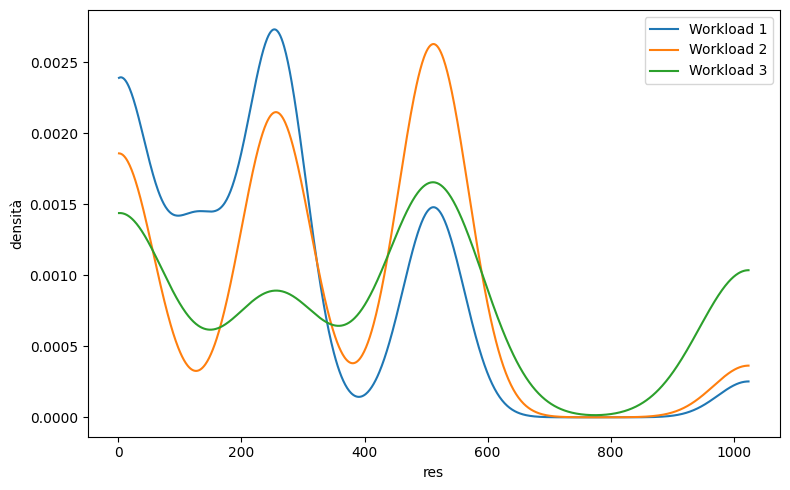

In [ ]:
# plot andamento

import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# --- file di input ---
files = [
    "workload_2000jobs_1024nodes_60.json",
    "workload_2000jobs_1024nodes_80.json",
    "workload_2000jobs_1024nodes_95.json",
]

labels = [
    "Workload 1",
    "Workload 2",
    "Workload 3",
]

# --- lettura dei res ---
all_res = []

for filename in files:
    with open(filename, "r") as f:
        data = json.load(f)

    res_values = [
        job["res"]
        for job in data.get("jobs", [])
        if job.get("res", 0) > 0
    ]

    all_res.append(np.array(res_values))

# --- dominio comune per le KDE ---
xmin = min(r.min() for r in all_res)
xmax = max(r.max() for r in all_res)
x = np.linspace(xmin, xmax, 1000)

# --- plot ---
plt.figure(figsize=(8, 5))

for res, label in zip(all_res, labels):
    kde = gaussian_kde(res)
    y = kde(x)
    plt.plot(x, y, label=label)

plt.xlabel("res")
plt.ylabel("densità")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#da summary a results con somme energy
# 


import csv
import os

# cartella con i CSV di input
INPUT_DIR = "../../output_files/experiment1_review/"
OUTPUT_FILE = "energy_summary.csv"

results = []

for filename in os.listdir(INPUT_DIR):
    if not filename.endswith(".csv"):
        continue

    filepath = os.path.join(INPUT_DIR, filename)
    total_energy = 0.0

    with open(filepath, newline="") as f:
        reader = csv.DictReader(f, delimiter=";")
        print(reader.fieldnames)
        for row in reader:
            if row['energy']:
                total_energy += float(row['energy'])

    results.append((filename, total_energy))

# scrittura CSV finale
with open(OUTPUT_FILE, "w", newline="") as f:
    writer = csv.writer(f, delimiter=";")
    writer.writerow(["nome_file", "sum_energy"])
    for name, energy in results:
        writer.writerow([name, energy])

print(f"Creato file: {OUTPUT_FILE}")

['tag', 'job_id', 'start_time', 'end_time', 'average power', 'average powercap', 'requested power', 'energy', 'num_nodes', '']
['tag', 'job_id', 'start_time', 'end_time', 'average power', 'average powercap', 'requested power', 'energy', 'num_nodes', '']
['tag', 'job_id', 'start_time', 'end_time', 'average power', 'average powercap', 'requested power', 'energy', 'num_nodes', '']
['tag', 'job_id', 'start_time', 'end_time', 'average power', 'average powercap', 'requested power', 'energy', 'num_nodes', '']
['tag', 'job_id', 'start_time', 'end_time', 'average power', 'average powercap', 'requested power', 'energy', 'num_nodes', '']
['tag', 'job_id', 'start_time', 'end_time', 'average power', 'average powercap', 'requested power', 'energy', 'num_nodes', '']
['tag', 'job_id', 'start_time', 'end_time', 'average power', 'average powercap', 'requested power', 'energy', 'num_nodes', '']
['tag', 'job_id', 'start_time', 'end_time', 'average power', 'average powercap', 'requested power', 'energy', '